                                   Descripción Tipo Clave  Conteo por Clave
0                     Broncoscopia fibroóptica    D  3322               275
1                            Otra broncoscopia    D  3323               162
2  Drenaje de cavidad pleural por toracoscopía    Q  3406               135
3                            Otra septoplastia    Q  2188               126
4           Laringoscopia y otra traqueoscopia    D  3142               122


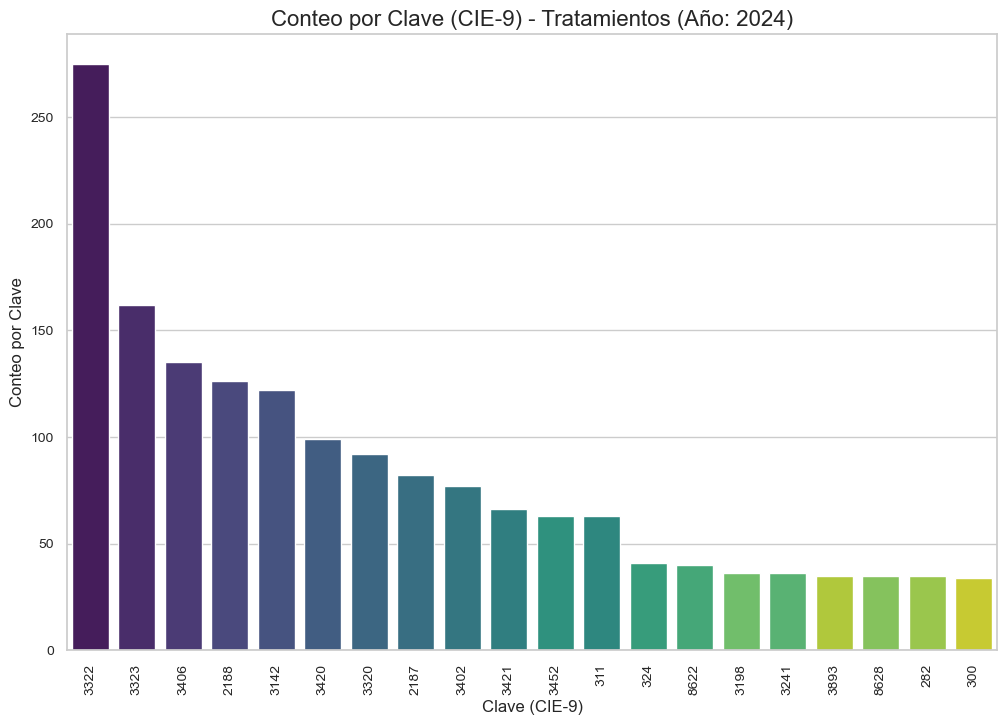

In [13]:
import pandas as pd
import seaborn as sns
import os
from dotenv import load_dotenv

import matplotlib.pyplot as plt

# Cargar el archivo CSV
file_path = "resultado_procesado_QUERY_qx.csv"
# Cargar variables de entorno desde el archivo .env
load_dotenv()

# ------------------------------- FUNCIONES ---------------------------------

# Funcion para obtener columnas numéricas
def get_numeric_columns(df):
    return df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Funcion para mostrar o guardar gráficos
def show_or_save_plot(plot, filename=None):
    if filename:
        plot.savefig(filenam, dpi=300, bbox_inches='tight')
    else:
        plt.show()

# ------------------------------- CONFIGURACION ------------------------------

# configuracion global para graficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
# ------------------------------- CARGA DE DATOS -----------------------------

# Cargar el archivo CSV
file_path = "resultado_procesado_QUERY_qx.csv"
# Cargar variables de entorno desde el archivo .env
load_dotenv()

# Obtener el directorio base desde la variable de entorno DATA_PATH
data_path = os.getenv('DATA_PATH')

if data_path:
    full_path = os.path.join(data_path, file_path)
    if os.path.exists(full_path):
        data = pd.read_csv(full_path)
    else:
        raise FileNotFoundError(f"El archivo especificado no existe en la ruta: {full_path}")
else:
    raise FileNotFoundError("La variable de entorno DATA_PATH no está configurada. Por favor, verifica el archivo .env o configura la variable correctamente.")

# Mostrar las primeras filas del DataFrame
print(data.head())

# ------------------------------- EJEMPLO VISUALIZACIÓN --------------------------

# Ejemplo de visualización: Histograma de una columna numérica
if not data.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=data.head(20), 
        x='Clave', 
        y='Conteo por Clave', 
        hue='Clave', 
        dodge=False, 
        palette="viridis", 
        order=data.sort_values('Conteo por Clave', ascending=False)['Clave'].head(20)
    )
    plt.title('Conteo por Clave (CIE-9) - Tratamientos (Año: 2024)', fontsize=16)
    plt.xlabel('Clave (CIE-9)', fontsize=12)
    plt.ylabel('Conteo por Clave', fontsize=12)
    plt.xticks(rotation=90)
    plt.legend([], [], frameon=False)  # Remove legend
    plt.show()
else:
    print("El archivo está vacío o no contiene datos.")


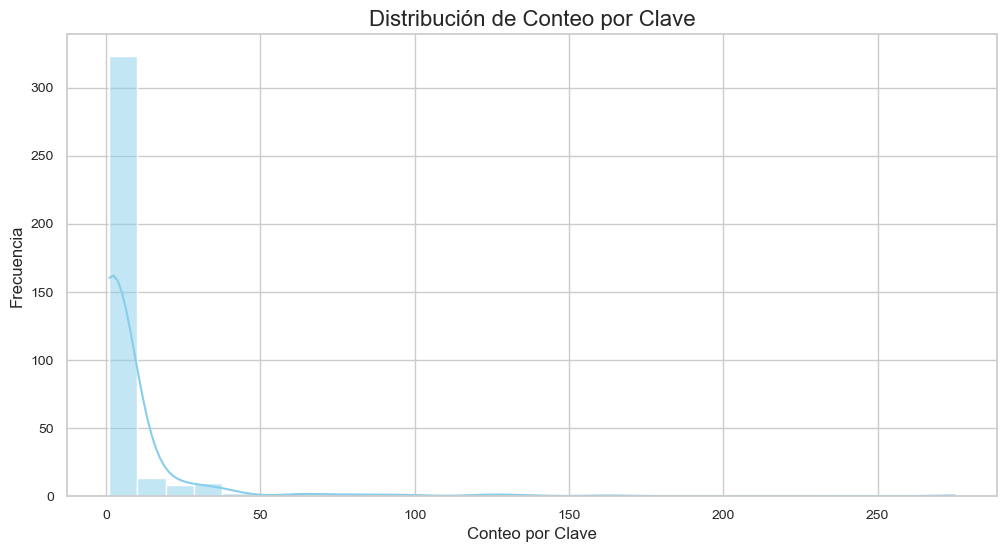

C:\Users\David Escudero\AppData\Local\Temp\ipykernel_17836\3850072164.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Tipo', order=data['Tipo'].value_counts().index, palette="viridis")


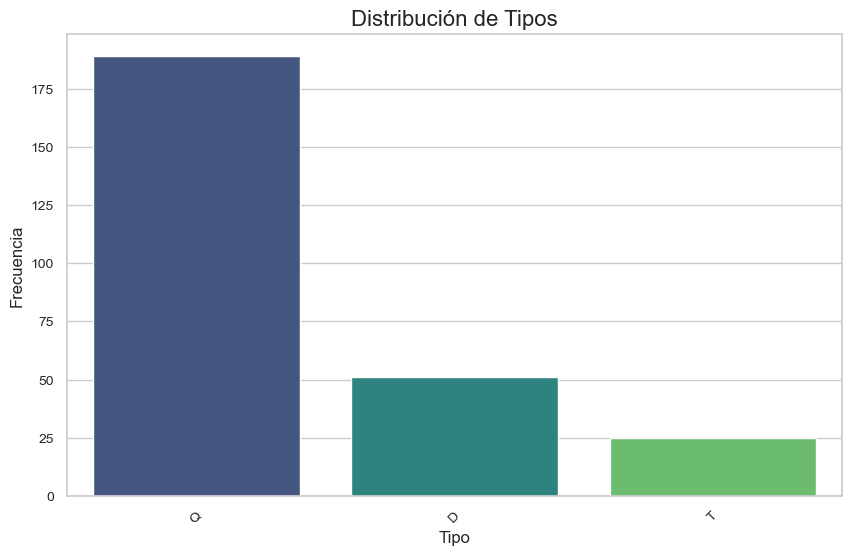

C:\Users\David Escudero\AppData\Local\Temp\ipykernel_17836\3850072164.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Conteo por Clave', y='Descripción', palette="mako")


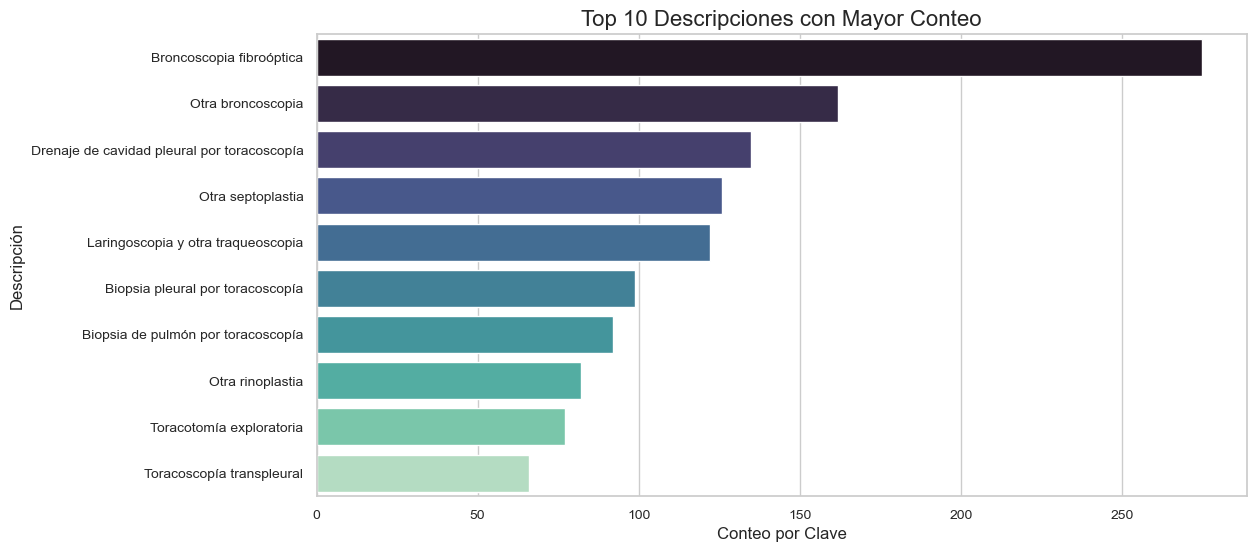

C:\Users\David Escudero\AppData\Local\Temp\ipykernel_17836\3850072164.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Tipo', y='Conteo por Clave', palette="coolwarm")


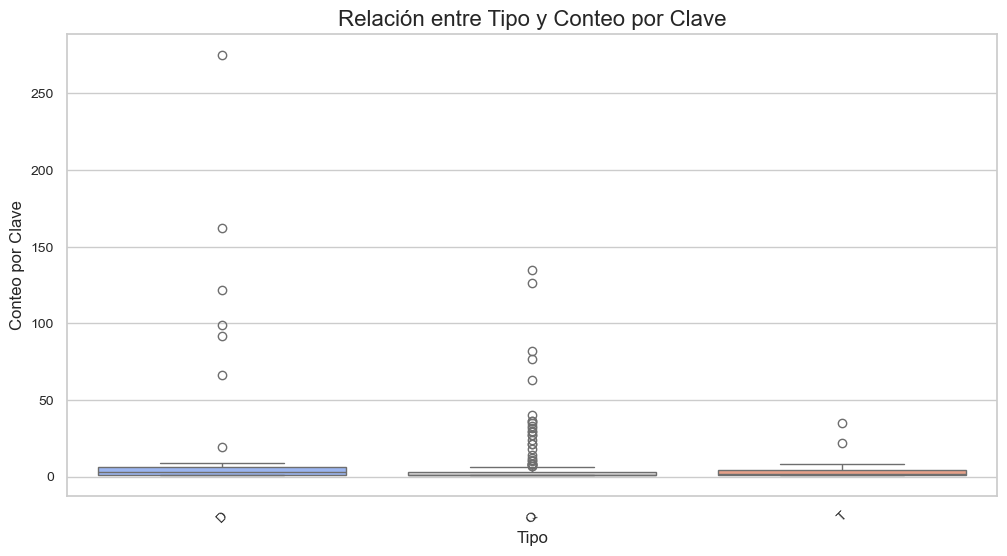

No hay suficientes columnas numéricas para generar un mapa de calor.


In [17]:
# Verificar si las columnas necesarias existen
for col in required_columns:
    if col not in data.columns:
        print(f"La columna '{col}' no está presente en el DataFrame.")

# Visualización 1: Distribución de la columna numérica 'Conteo por Clave'
plt.figure(figsize=(12, 6))
sns.histplot(data['Conteo por Clave'], kde=True, bins=30, color="skyblue")
plt.title('Distribución de Conteo por Clave', fontsize=16)
plt.xlabel('Conteo por Clave', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
show_or_save_plot(plt)

# Visualización 2: Conteo de valores únicos en la columna 'Tipo'
if 'Tipo' in data.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x='Tipo', order=data['Tipo'].value_counts().index, palette="viridis")
    plt.title('Distribución de Tipos', fontsize=16)
    plt.xlabel('Tipo', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.xticks(rotation=45)
    show_or_save_plot(plt)

# Visualización 3: Top 10 de descripciones con mayor conteo
top_10 = data.nlargest(10, 'Conteo por Clave')
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='Conteo por Clave', y='Descripción', palette="mako")
plt.title('Top 10 Descripciones con Mayor Conteo', fontsize=16)
plt.xlabel('Conteo por Clave', fontsize=12)
plt.ylabel('Descripción', fontsize=12)
show_or_save_plot(plt)

# Visualización 4: Relación entre 'Tipo' y 'Conteo por Clave'
if 'Tipo' in data.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data, x='Tipo', y='Conteo por Clave', palette="coolwarm")
    plt.title('Relación entre Tipo y Conteo por Clave', fontsize=16)
    plt.xlabel('Tipo', fontsize=12)
    plt.ylabel('Conteo por Clave', fontsize=12)
    plt.xticks(rotation=45)
    show_or_save_plot(plt)

# Visualización 5: Heatmap de correlación (si hubiera más columnas numéricas)
if len(numeric_columns) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = data[numeric_columns].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title('Mapa de Calor de Correlaciones', fontsize=16)
    show_or_save_plot(plt)
else:
    print("No hay suficientes columnas numéricas para generar un mapa de calor.")
